In [1]:
import analysis_utils as utils
import pandas as pd
import numpy as np
import importlib
from sklearn.model_selection import GroupShuffleSplit

importlib.reload(utils)
print("Loading Data & Generating Artifacts...")
df, metrics, exp_info = utils.load_data_universal("db/results.sqlite")

df = df[df['Length'] <= 500].copy()

df = df[df['Length'] <= 500].copy()

# 2. Initialize the Group Splitter
# n_splits=1 gives you a single train/test split (like train_test_split)
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state= 42)

# 3. Generate the indices
# We pass the 'question_id_external' column as the 'groups' parameter
train_idx, test_idx = next(gss.split(df, groups=df['question_id_external']))

# 4. Create your new DataFrames
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Loading Data & Generating Artifacts...
Loading Run: HUV_Benchmark_Optimized (ID: 1)
Train shape: (2699, 27)
Test shape: (1175, 27)


### Full Logistic Regression Analysis

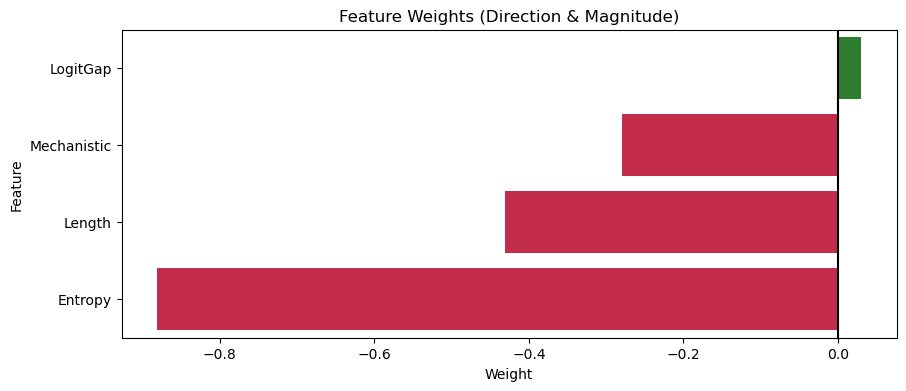

              precision    recall  f1-score   support

           0       0.37      0.70      0.48       188
           1       0.93      0.77      0.84       987

    accuracy                           0.76      1175
   macro avg       0.65      0.74      0.66      1175
weighted avg       0.84      0.76      0.78      1175



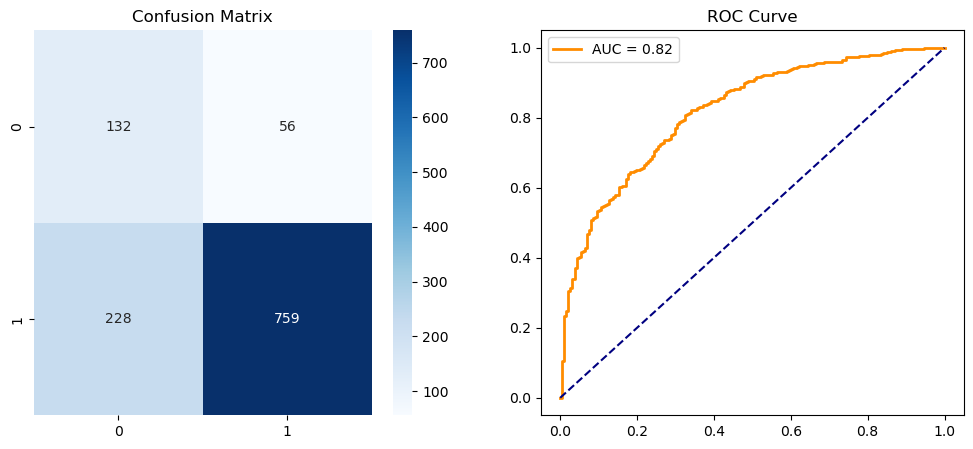

### Full Logistic Regression Analysis

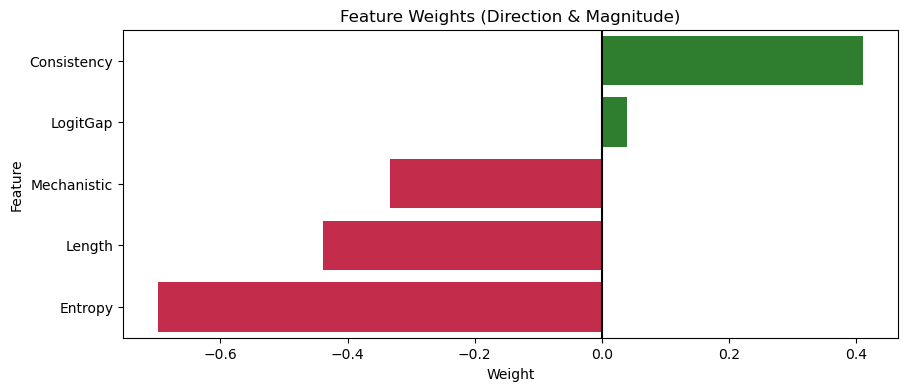

              precision    recall  f1-score   support

           0       0.38      0.73      0.50       188
           1       0.94      0.77      0.85       987

    accuracy                           0.77      1175
   macro avg       0.66      0.75      0.68      1175
weighted avg       0.85      0.77      0.79      1175



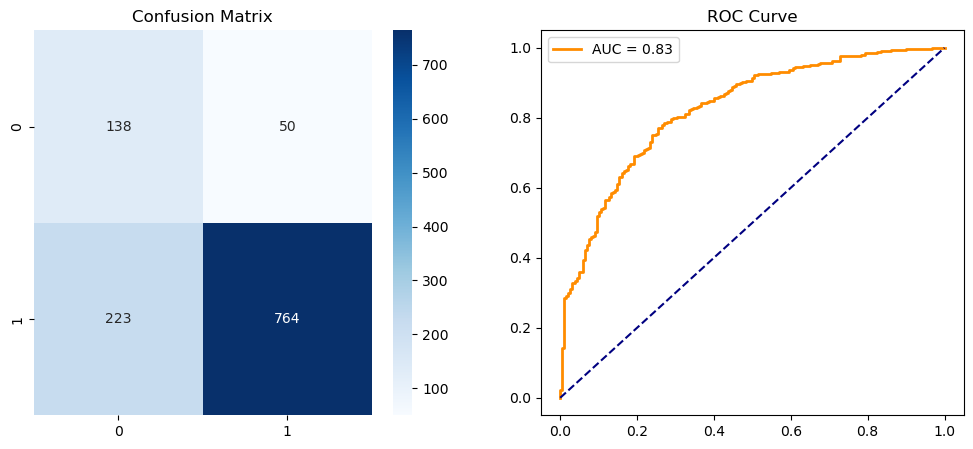

Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+2.56 SD,0.168,0.159,0.05,
LogitGap,-0.22 SD,0.022,0.022,0.03,
Mechanistic,+1.38 SD,0.979,0.978,0.00,
Length,+0.21 SD,294.704,283.850,86.43,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+0.57 SD,0.077,0.079,0.02,
LogitGap,+0.13 SD,0.051,0.052,0.05,
Mechanistic,+0.47 SD,0.970,0.970,0.00,
Length,-0.52 SD,227.112,224.849,45.65,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis


Generating t-SNE on Train & Test Analysis...


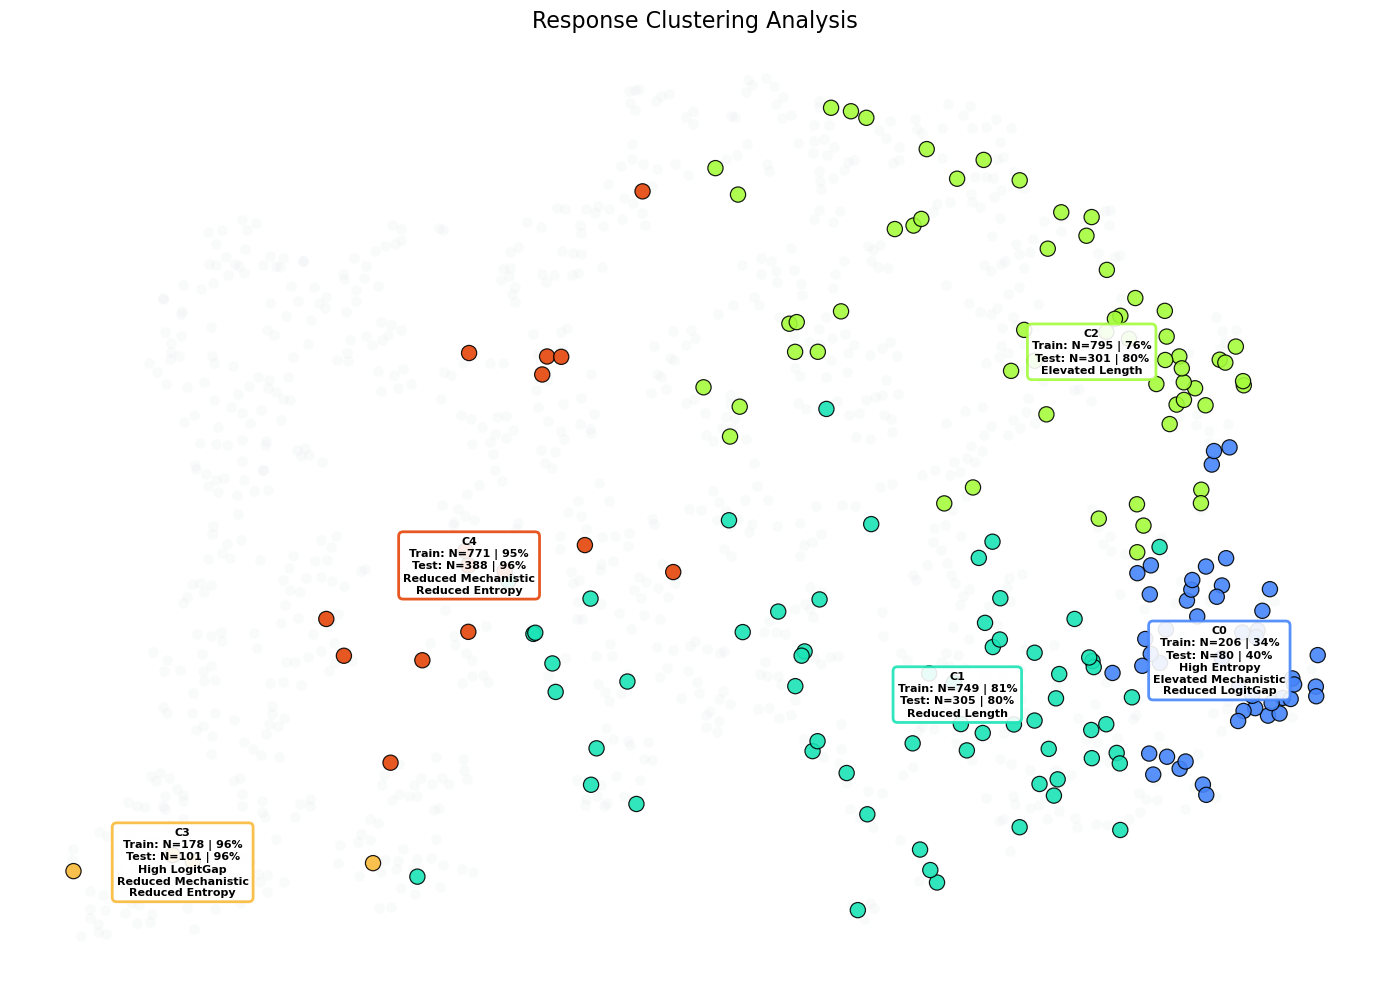

In [2]:


metrics_to_use = ['Entropy', 'LogitGap', 'Mechanistic','Length'] # 'Consistency', 

logistic_predictor = utils.run_detailed_logistic_regression(train_df, features=metrics_to_use, test_df = test_df)

logistic_predictor_with_consistency = utils.run_detailed_logistic_regression(train_df, features=metrics_to_use + ["Consistency"], test_df = test_df)

cluster_predictor = utils.run_failure_modes_dashboard(train_df, exp_info, features=metrics_to_use, test_df = test_df, min_clusters = 5)

In [3]:
# 1. Capture Logistic Fusion Probabilities (Index 0)
df['Logistic_Fusion'], _ = logistic_predictor(df)

# 1. Capture Logistic Fusion Probabilities (Index 0)
df['Logistic_Fusion_Consistency'], _ = logistic_predictor_with_consistency(df)

# 2. Capture Cluster Labels (Index 1)
_, df['Cluster_Label'] = cluster_predictor(df)

# 3. (Optional) Capture Cluster Confidence if needed
df['Cluster_Conf'], _ = cluster_predictor(df)

# Verify
print(df[['Logistic_Fusion', 'Cluster_Label']].head())

   Logistic_Fusion Cluster_Label
0         0.817988     Cluster 3
1         0.896099     Cluster 3
2         0.892788     Cluster 3
3         0.897047     Cluster 3
4         0.516819     Cluster 2


In [4]:
utils.run_comparison_dashboard(train_df, logistic_predictor, cluster_predictor, metrics_to_use, test_df = test_df)

,Train AUROC,Train ECE,Train MSE,Test AUROC,Test ECE,Test MSE
Model,,,,,,
Logistic Fusion,0.7903,0.2356,0.1804,0.8184,0.2468,0.1721
Cluster Baseline,0.7380,0.0000,0.1291,0.7380,0.0194,0.1149
Entropy,0.7525,0.0391,0.1339,0.8114,0.0464,0.1135
LogitGap,0.3651,0.1650,0.1888,0.3702,0.1486,0.1636
Mechanistic,0.2492,0.1794,0.1832,0.2333,0.1920,0.1699
Length,0.6380,0.3401,0.2660,0.6156,0.3488,0.2620


Model,Mn,Rg
Logistic Fusion,0.13,0.25
Cluster Baseline,0.34,0.00
Entropy,0.61,0.66
LogitGap,0.97,0.21
Mechanistic,0.90,0.30
Length,0.46,0.92
Model,Mn,Rg
Logistic Fusion,0.53,0.55
Cluster Baseline,0.81,0.00
Entropy,0.81,0.32


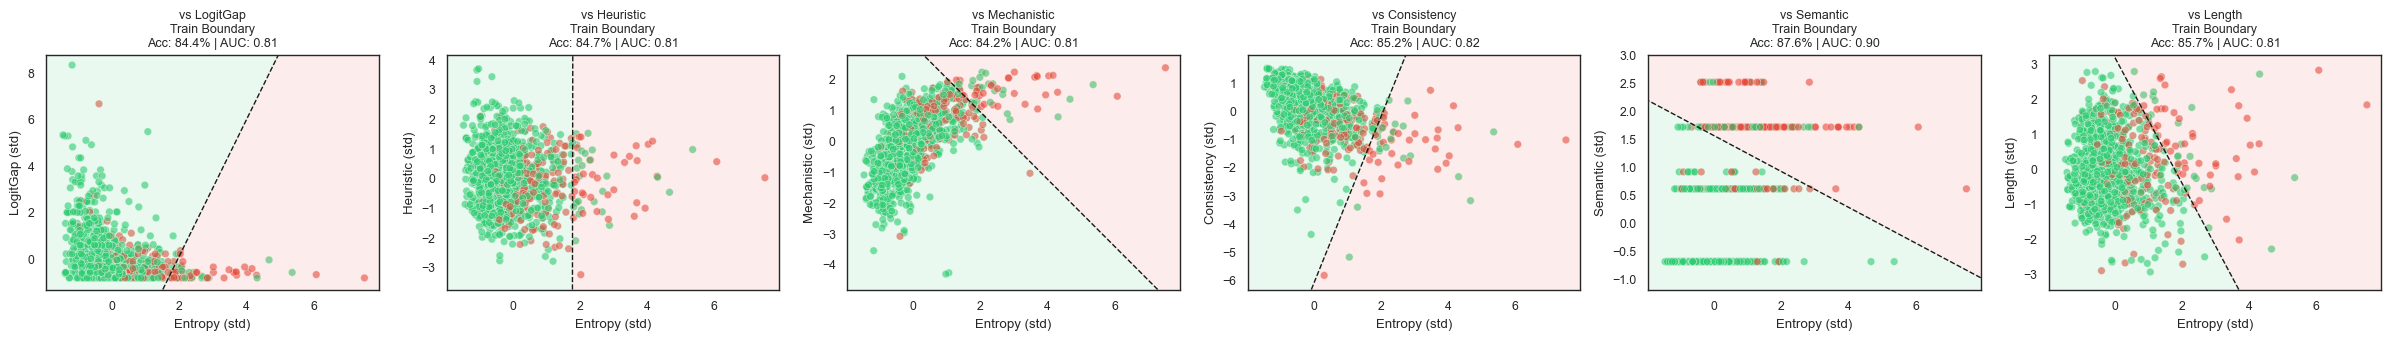

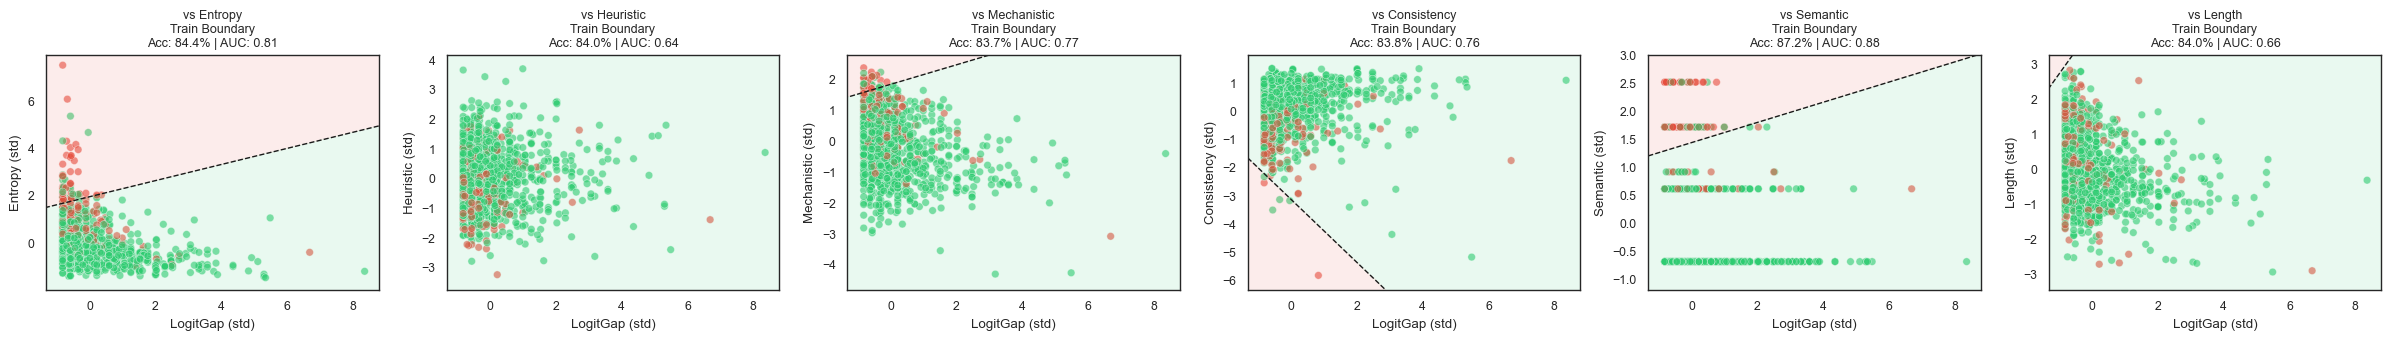

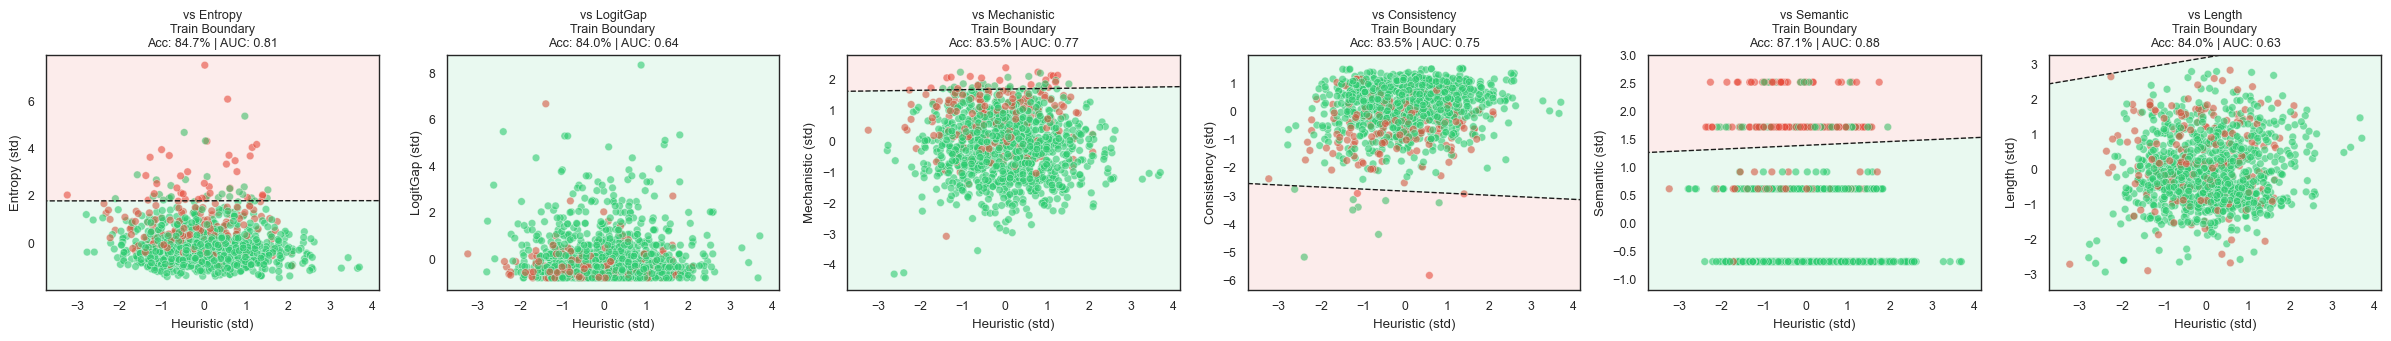

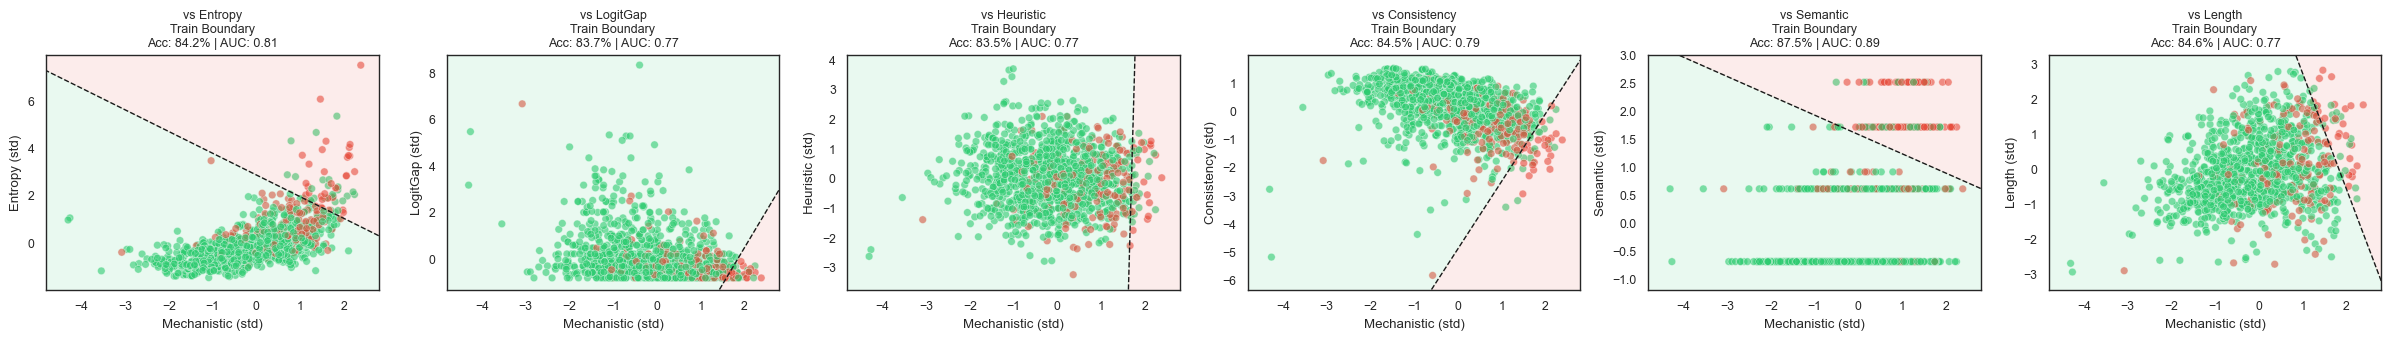

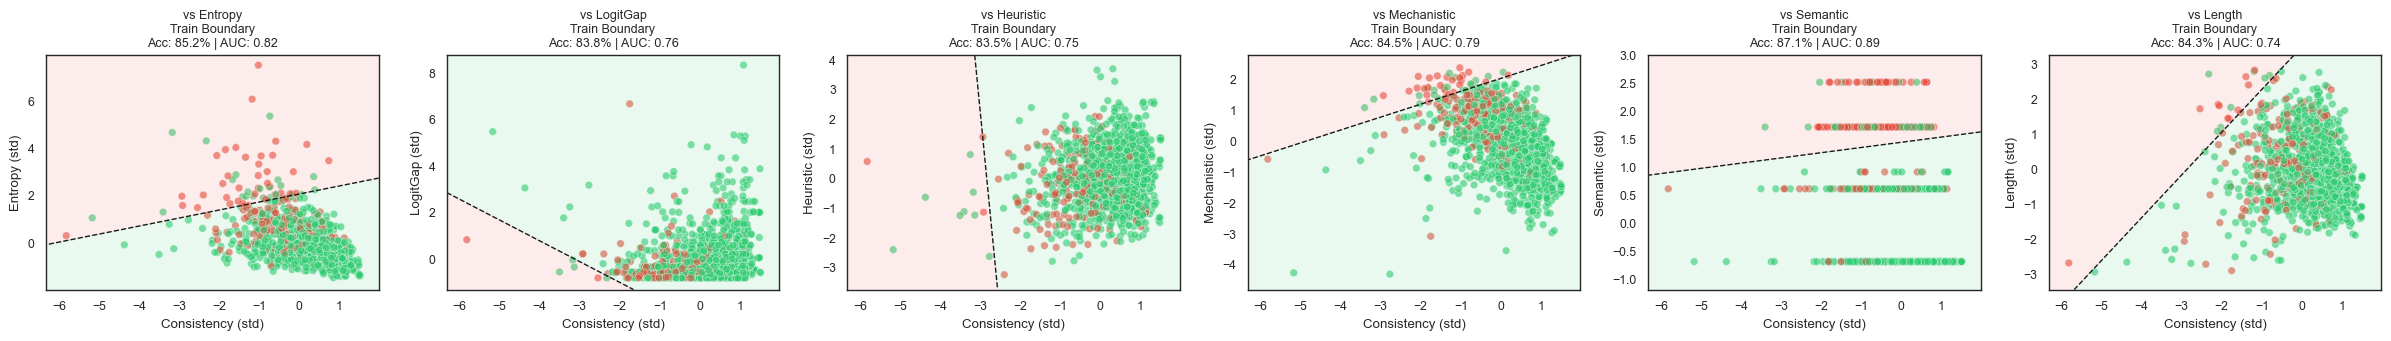

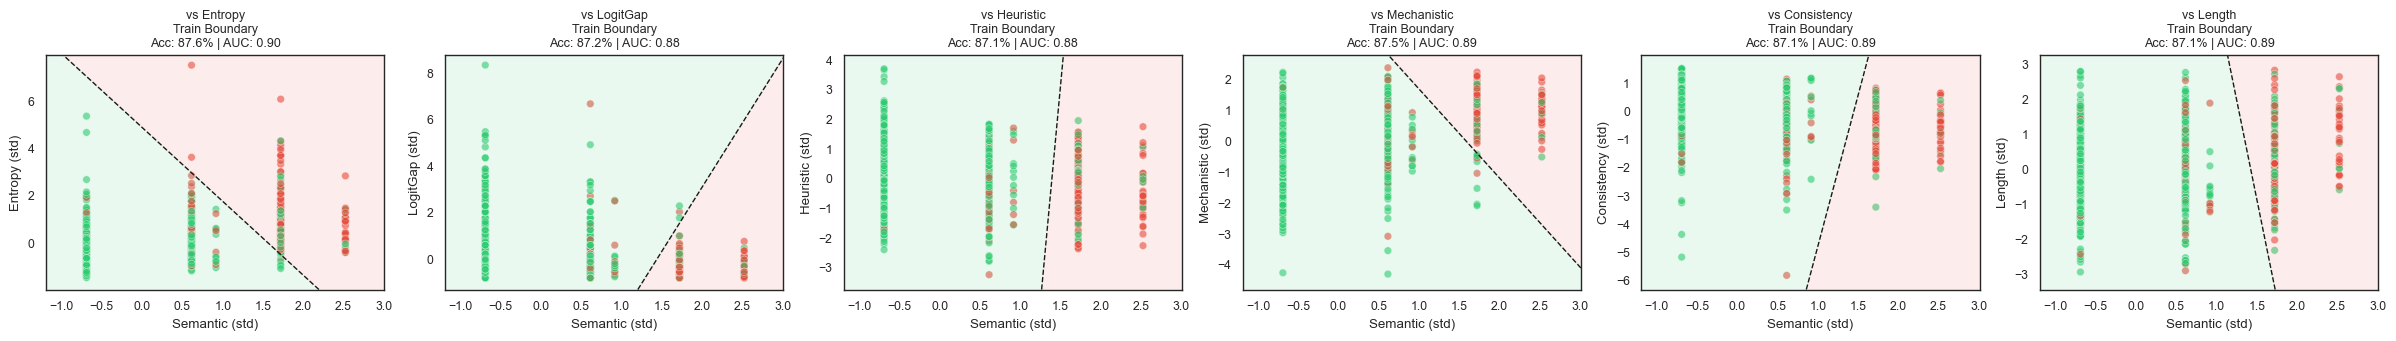

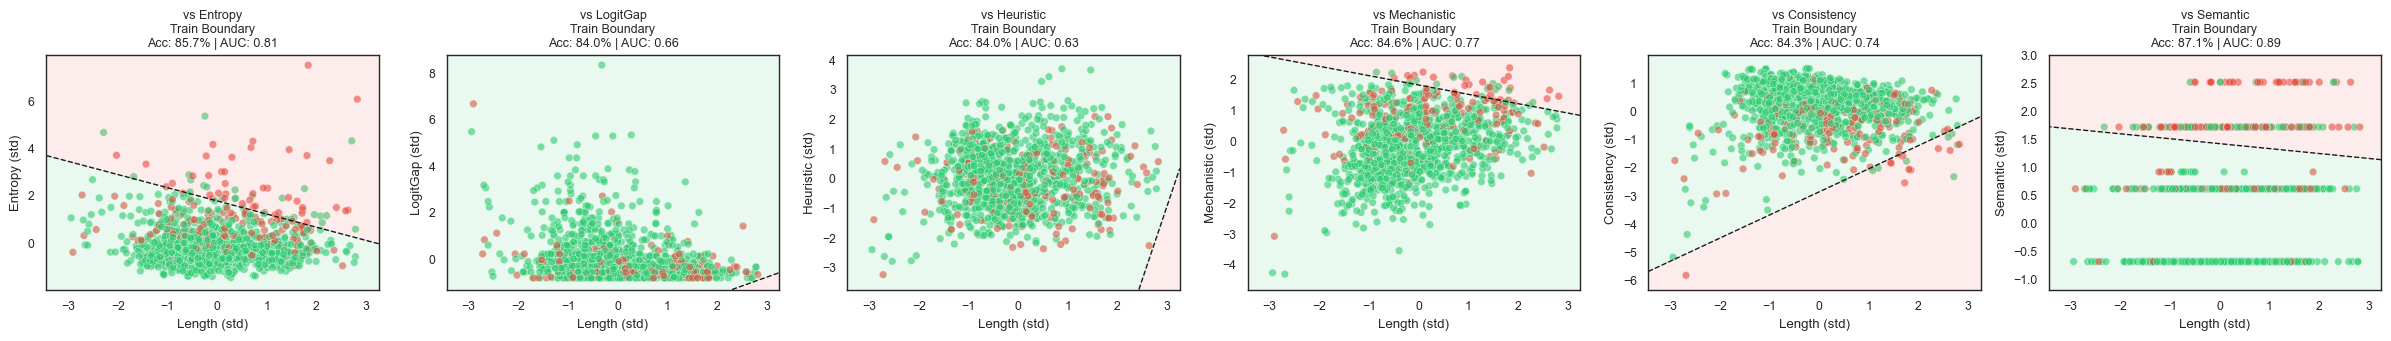

{'Entropy': <analysis_utils.PredictorArtifact at 0x340feb850>,
 'LogitGap': <analysis_utils.PredictorArtifact at 0x35900b410>,
 'Heuristic': <analysis_utils.PredictorArtifact at 0x3478f2c10>,
 'Mechanistic': <analysis_utils.PredictorArtifact at 0x33f4c6e50>,
 'Consistency': <analysis_utils.PredictorArtifact at 0x34c244a10>,
 'Semantic': <analysis_utils.PredictorArtifact at 0x35988b110>,
 'Length': <analysis_utils.PredictorArtifact at 0x35932e910>}

In [5]:
utils.run_full_analysis(train_df,metrics, test_df = test_df)

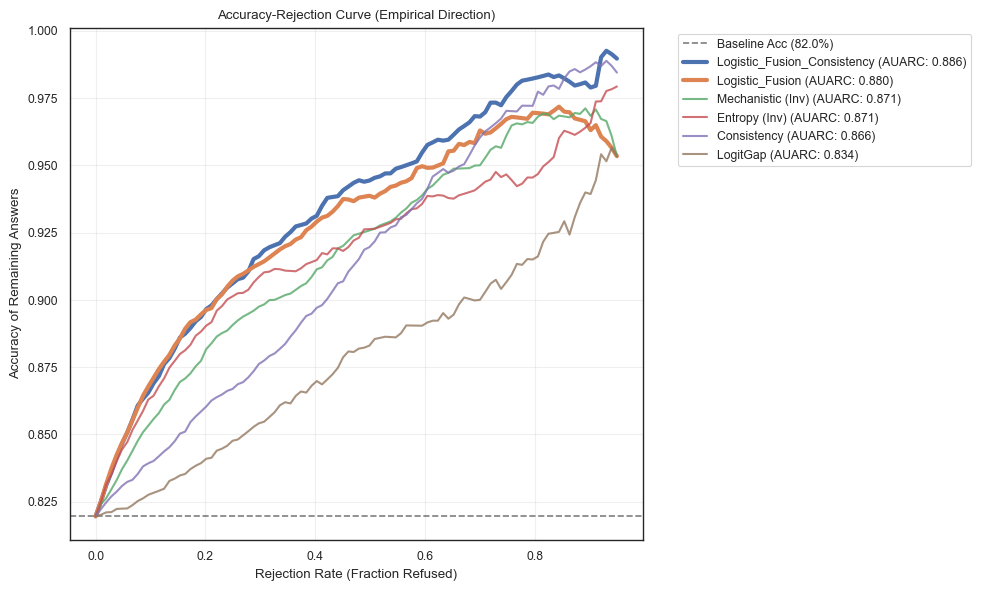

In [6]:
cluster_accs = df.groupby('Cluster_Label')['Correct'].mean()
df['Cluster Baseline'] = df['Cluster_Label'].map(cluster_accs)

metrics_to_plot = ["Logistic_Fusion_Consistency", "Logistic_Fusion", "Mechanistic", "Entropy", "Consistency", "LogitGap"] 

utils.plot_auarc_analysis(df, metrics_to_plot)

In [7]:
df.keys()

Index(['result_id', 'question_id_external', 'question_text', 'gold_answer',
       'predicted_answer', 'full_trace_text', 'is_correct', 'Entropy',
       'LogitGap', 'Heuristic', 'Mechanistic', 'Consistency',
       'similarity_vector', 'uq_tokens', 'uq_mech_trace', 'uq_entropy_trace',
       'uq_logit_gap_trace', 'Correct', 'Semantic', 'Length', 'Entropy_Z',
       'LogitGap_Z', 'Heuristic_Z', 'Mechanistic_Z', 'Consistency_Z',
       'Semantic_Z', 'Length_Z', 'Logistic_Fusion',
       'Logistic_Fusion_Consistency', 'Cluster_Label', 'Cluster_Conf',
       'Cluster Baseline'],
      dtype='object')

In [8]:
utils.analyze_outlier_clusters(df)